In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

lab_master = pd.read_csv('/content/clean_lab_master_v3 (1).csv')
print("Loaded:", lab_master.shape)

Loaded: (76069, 18)


### Data Visualization: Distributions in `lab_master`

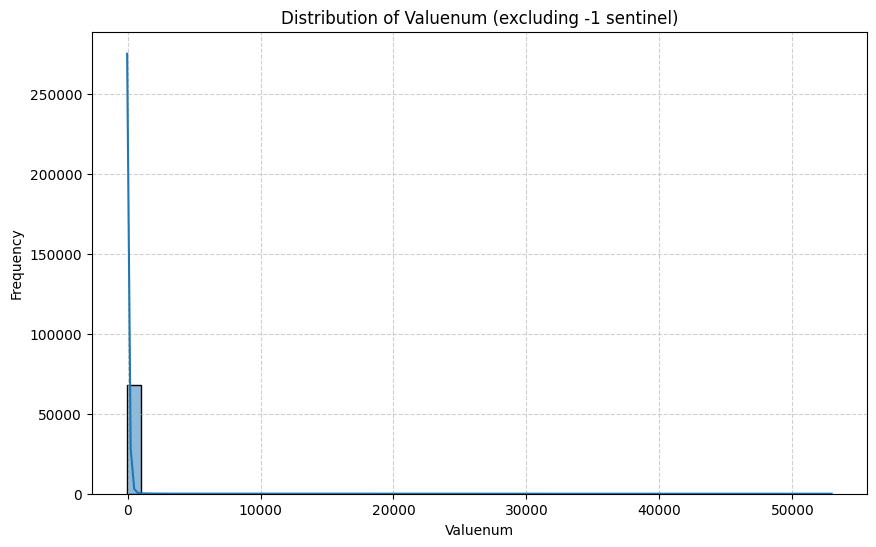

In [2]:
# Histogram of valuenum (remove -1 sentinel values)
plt.figure(figsize=(10, 6))
sns.histplot(lab_master[lab_master['valuenum'] != -1]['valuenum'], bins=50, kde=True)
plt.title('Distribution of Valuenum (excluding -1 sentinel)')
plt.xlabel('Valuenum')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

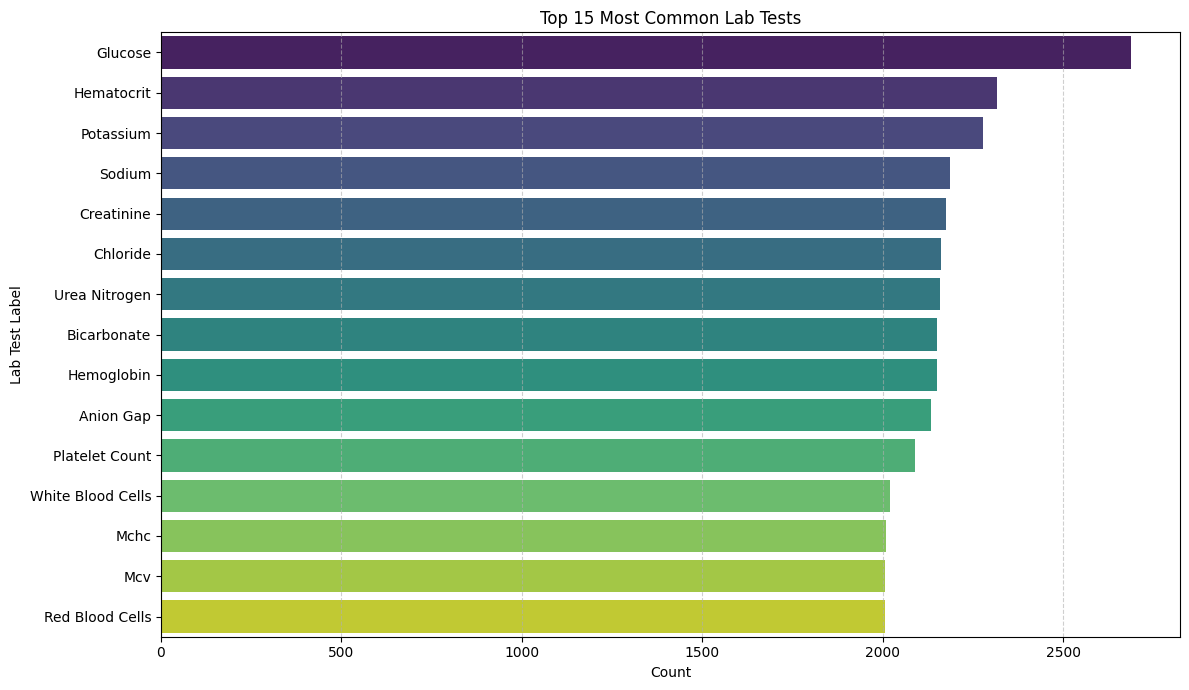

In [3]:
# Bar chart of top 15 most common lab tests (label column)
plt.figure(figsize=(12, 7))
top_15_labels = lab_master['label'].value_counts().nlargest(15)
sns.barplot(x=top_15_labels.values, y=top_15_labels.index, palette='viridis', hue=top_15_labels.index, legend=False)
plt.title('Top 15 Most Common Lab Tests')
plt.xlabel('Count')
plt.ylabel('Lab Test Label')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

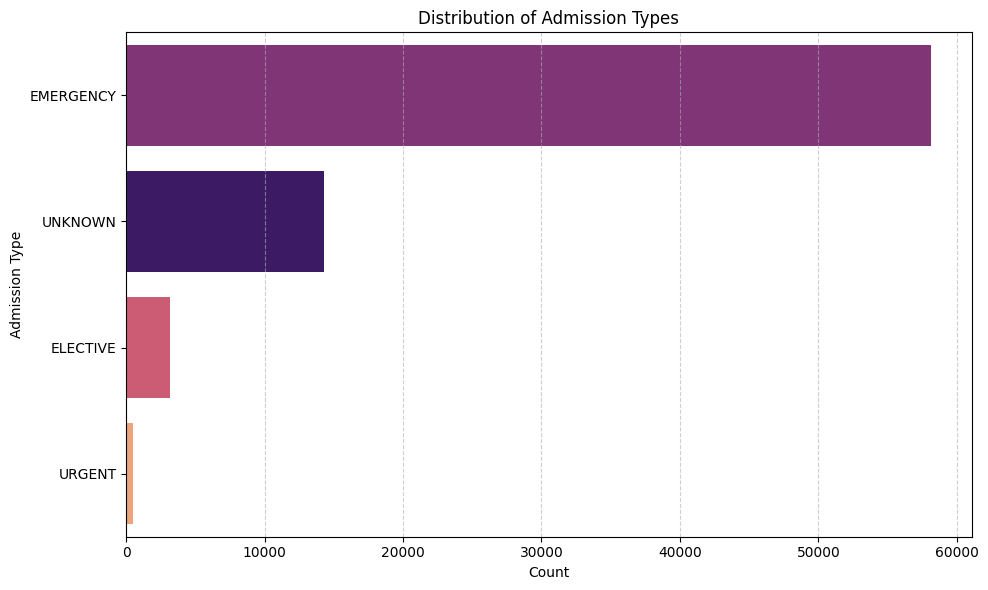

In [4]:
# Bar chart of admission_type value counts
plt.figure(figsize=(10, 6))
sns.countplot(y='admission_type', data=lab_master, order=lab_master['admission_type'].value_counts().index, palette='magma', hue='admission_type', legend=False)
plt.title('Distribution of Admission Types')
plt.xlabel('Count')
plt.ylabel('Admission Type')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

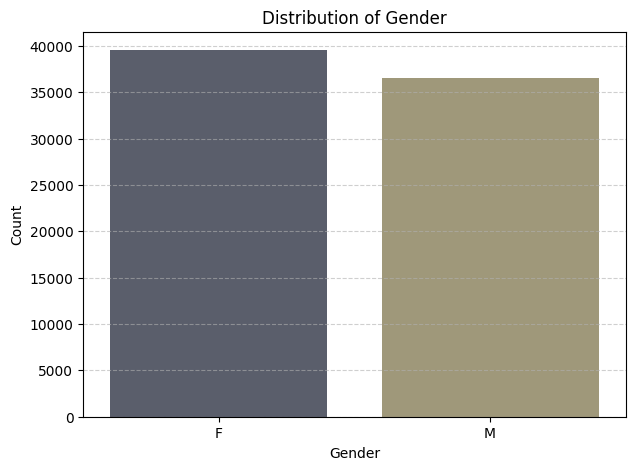

In [5]:
# Bar chart of gender value counts
plt.figure(figsize=(7, 5))
sns.countplot(x='gender', data=lab_master, palette='cividis', hue='gender', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Additional Data Visualizations for `lab_master`

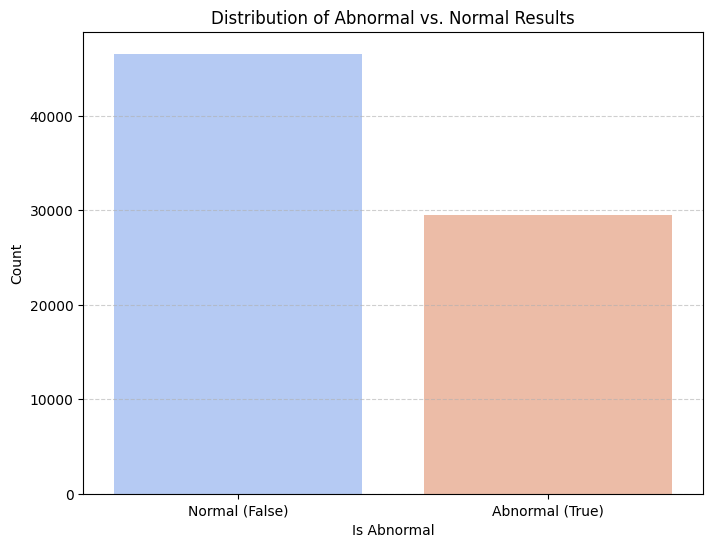

In [6]:
# Bar chart of IS_ABNORMAL value counts
plt.figure(figsize=(8, 6))
sns.countplot(x='is_abnormal', data=lab_master, palette='coolwarm', hue='is_abnormal', legend=False)
plt.title('Distribution of Abnormal vs. Normal Results')
plt.xlabel('Is Abnormal')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Normal (False)', 'Abnormal (True)'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

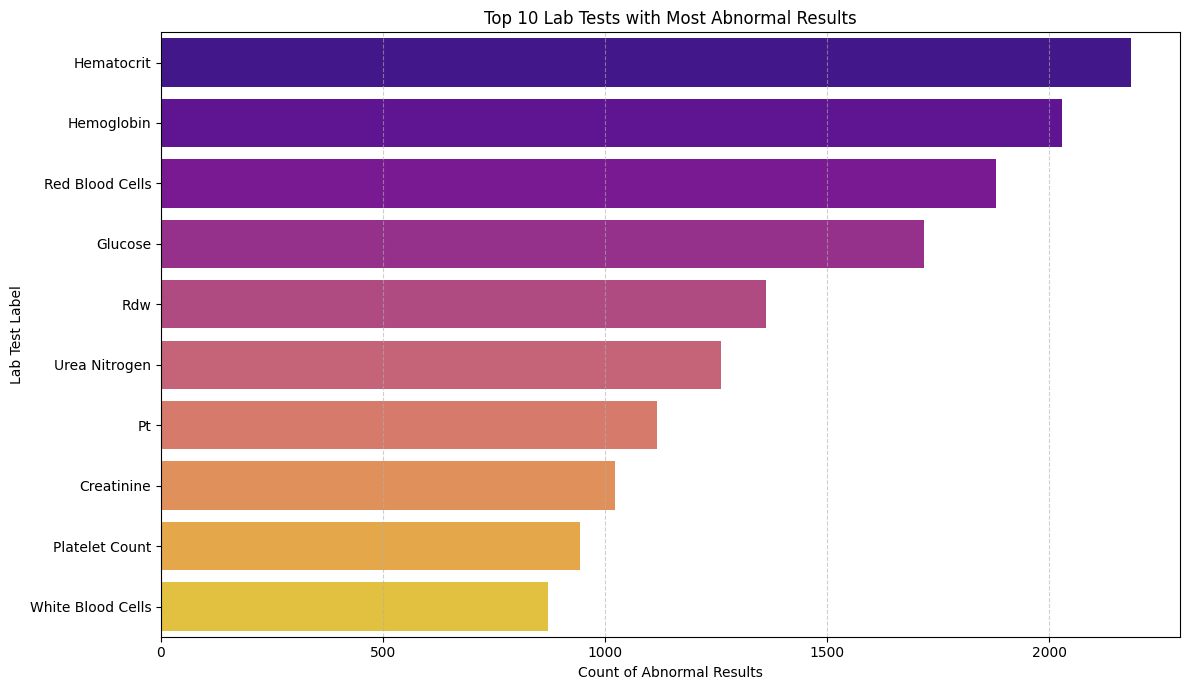

In [7]:
# Bar chart of top 10 lab tests (label) that have the most abnormal results
abnormal_tests = lab_master[lab_master['is_abnormal'] == True]
top_10_abnormal_labels = abnormal_tests['label'].value_counts().nlargest(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_abnormal_labels.values, y=top_10_abnormal_labels.index, palette='plasma', hue=top_10_abnormal_labels.index, legend=False)
plt.title('Top 10 Lab Tests with Most Abnormal Results')
plt.xlabel('Count of Abnormal Results')
plt.ylabel('Lab Test Label')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

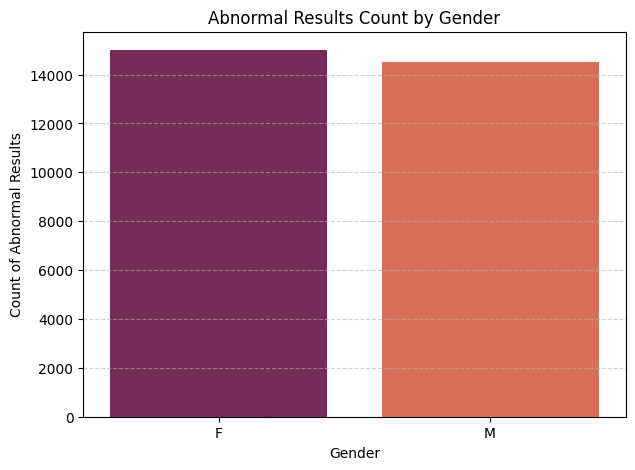

In [8]:
# Bar chart of abnormal results grouped by gender
abnormal_gender_counts = lab_master[lab_master['is_abnormal'] == True]['gender'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=abnormal_gender_counts.index, y=abnormal_gender_counts.values, palette='rocket', hue=abnormal_gender_counts.index, legend=False)
plt.title('Abnormal Results Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count of Abnormal Results')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Time-based Data Visualizations for `lab_master`

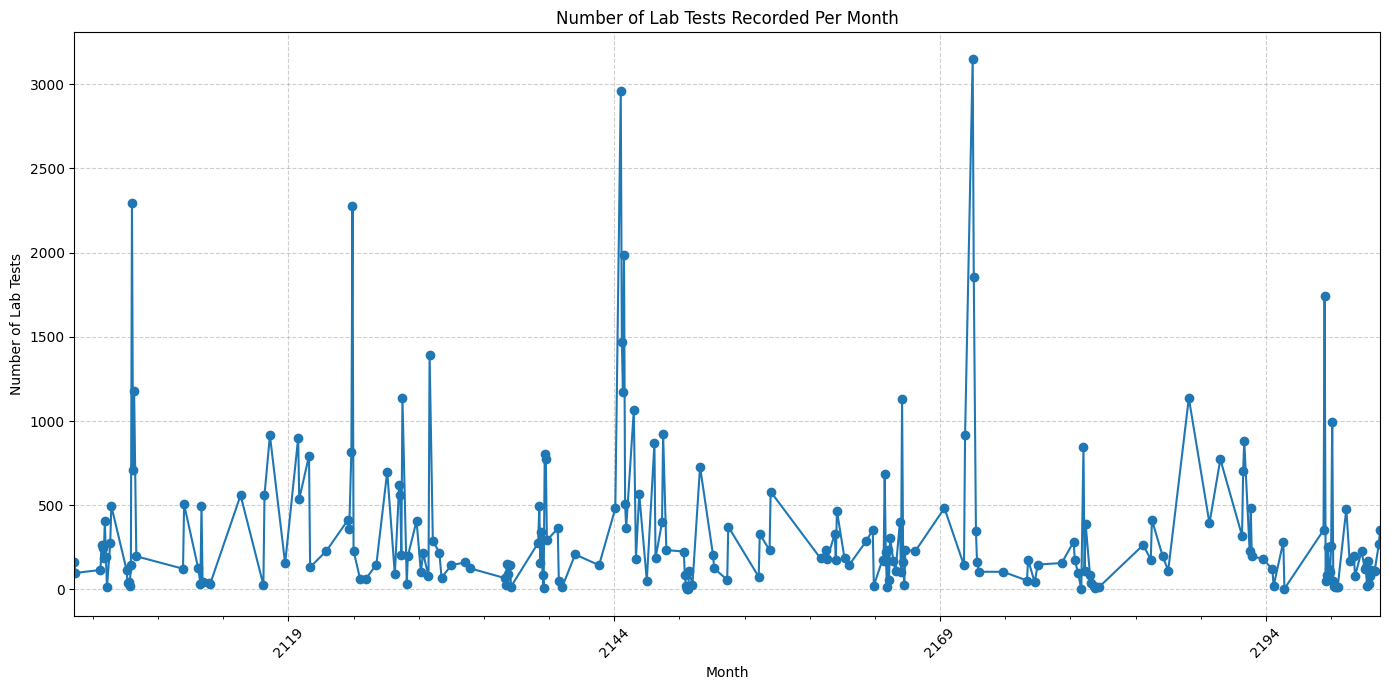

In [9]:
# Convert charttime to datetime if it's not already
if not pd.api.types.is_datetime64_any_dtype(lab_master['charttime']):
    lab_master['charttime'] = pd.to_datetime(lab_master['charttime'])

# Extract month and hour for analysis
lab_master['chart_month'] = lab_master['charttime'].dt.to_period('M')
lab_master['chart_hour'] = lab_master['charttime'].dt.hour

# Line chart of number of lab tests recorded per month
monthly_tests = lab_master['chart_month'].value_counts().sort_index()

plt.figure(figsize=(14, 7))
monthly_tests.plot(kind='line', marker='o')
plt.title('Number of Lab Tests Recorded Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Lab Tests')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

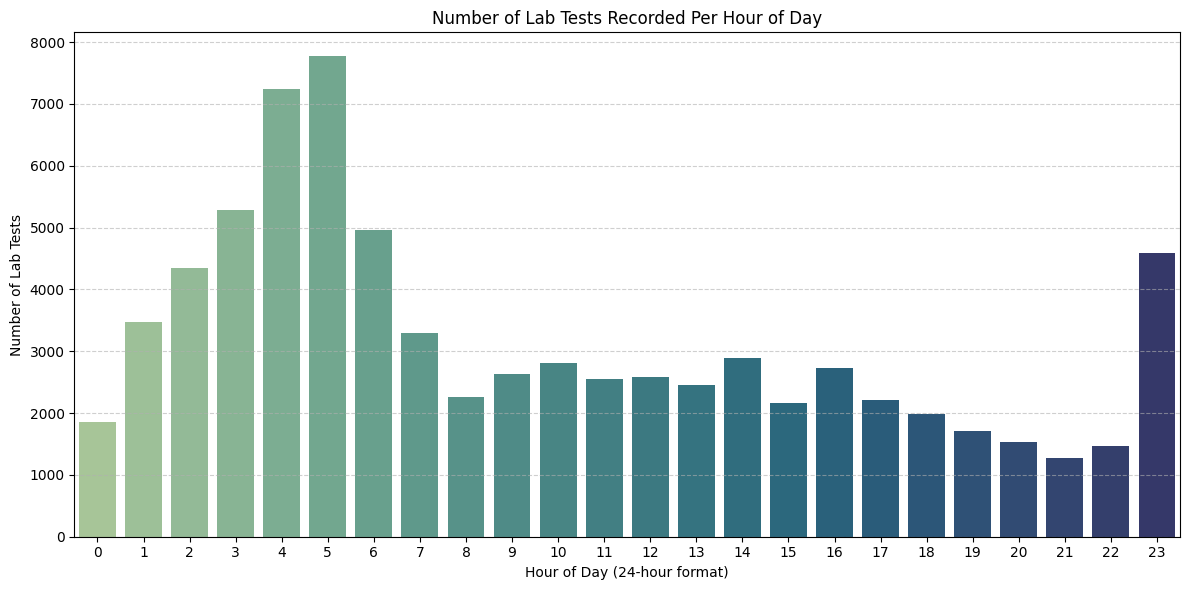

In [10]:
# Bar chart of lab tests recorded per hour of day
hourly_tests = lab_master['chart_hour'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_tests.index, y=hourly_tests.values, palette='crest', hue=hourly_tests.index, legend=False)
plt.title('Number of Lab Tests Recorded Per Hour of Day')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Lab Tests')
plt.xticks(range(0, 24)) # Ensure all hours are shown on x-axis
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Visualizations for Length of Stay (`los_days`)

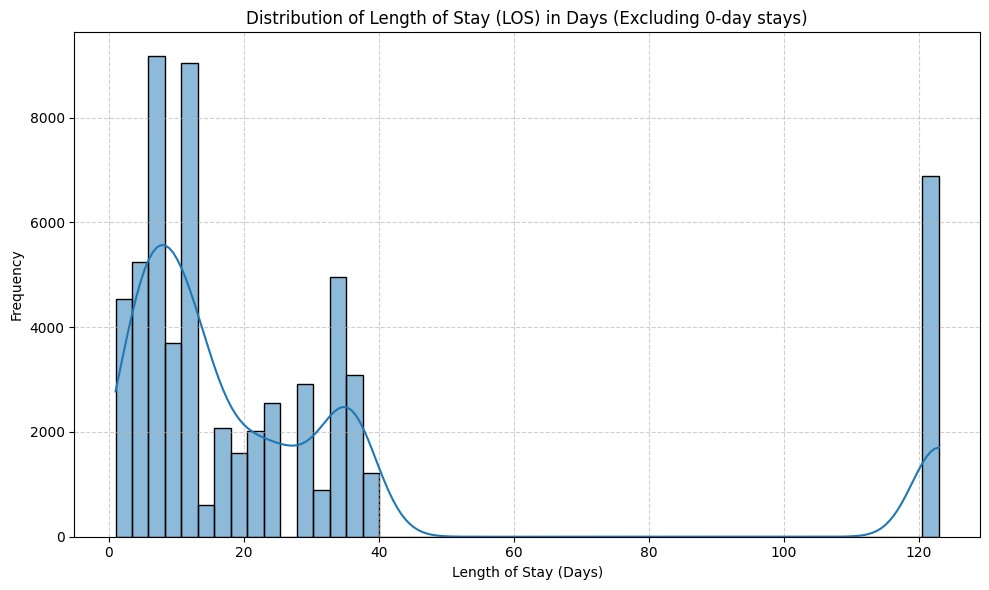

In [11]:
# Filter out rows where los_days is 0 for these visualizations
lab_master_filtered_los = lab_master[lab_master['los_days'] != 0].copy()

# Histogram of los_days distribution
plt.figure(figsize=(10, 6))
sns.histplot(lab_master_filtered_los['los_days'].dropna(), bins=50, kde=True)
plt.title('Distribution of Length of Stay (LOS) in Days (Excluding 0-day stays)')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

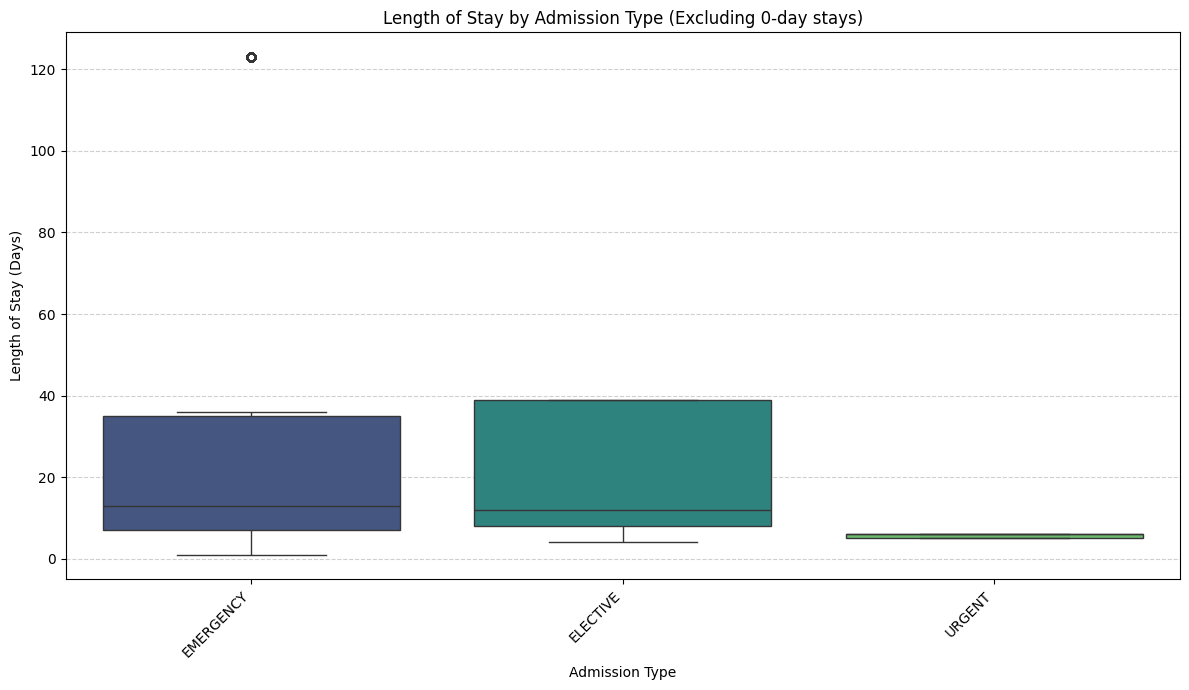

In [12]:
# Box plot of los_days grouped by admission_type
plt.figure(figsize=(12, 7))
sns.boxplot(x='admission_type', y='los_days', data=lab_master_filtered_los, palette='viridis', hue='admission_type', legend=False)
plt.title('Length of Stay by Admission Type (Excluding 0-day stays)')
plt.xlabel('Admission Type')
plt.ylabel('Length of Stay (Days)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

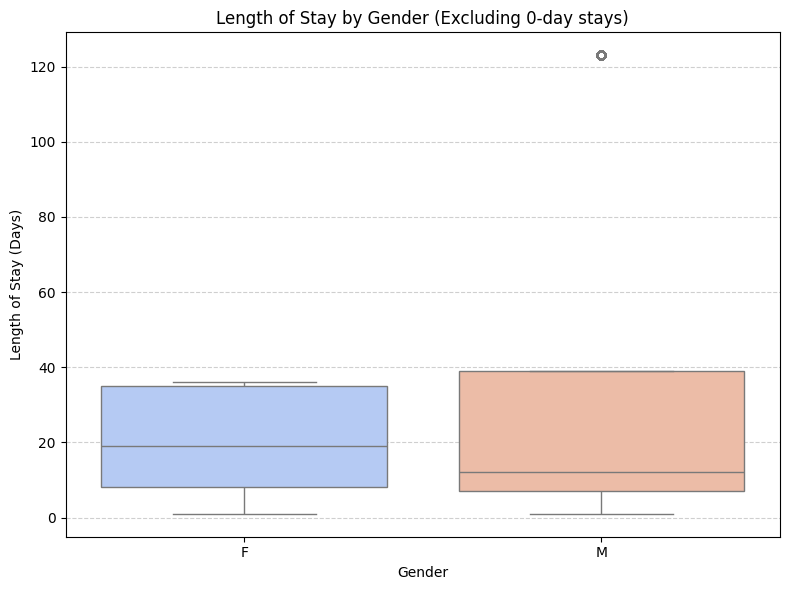

In [13]:
# Box plot of los_days grouped by gender
plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='los_days', data=lab_master_filtered_los, palette='coolwarm', hue='gender', legend=False)
plt.title('Length of Stay by Gender (Excluding 0-day stays)')
plt.xlabel('Gender')
plt.ylabel('Length of Stay (Days)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Correlation Analysis

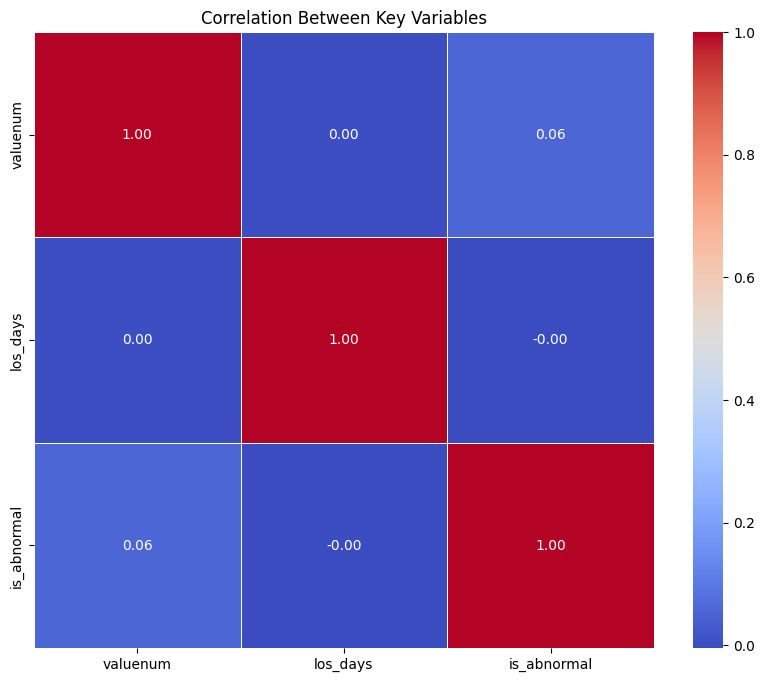

In [14]:
# Select only relevant numeric columns for correlation
correlation_data = lab_master[['valuenum', 'los_days', 'is_abnormal']].copy()

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Plot a heatmap of correlations using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Between Key Variables')
plt.show()